In [1]:
# 데이터 처리를 위한 pandas를 불러옵니다.
import pandas as pd

# 그래프를 그리기 위한 matplotlib와 seaborn을 불러옵니다.
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 파일을 저장하기 위해 os를 불러옵니다.
import os

# 윈도우에서 그래프 한글이 깨지지 않도록 맑은 고딕을 사용합니다.
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 그래프를 저장할 폴더가 없으면 만듭니다.
os.makedirs("images", exist_ok=True)

In [3]:
# 01_preprocessing.ipynb에서 만든 통합 데이터를 불러옵니다.
df = pd.read_csv(
    "../data/processed/violation_2017_2023.csv",
    encoding="utf-8-sig",
    parse_dates=["위반일자"]
)

# 데이터가 정상적으로 불러와졌는지 확인합니다.
print("데이터 크기:", df.shape)
print("기간:", df["위반일자"].min(), "~", df["위반일자"].max())
display(df.head())

데이터 크기: (681828, 10)
기간: 2017-01-01 00:00:00 ~ 2023-12-31 00:00:00


,구분,위반일자,위반시간,위반장소,과태료부과일자,데이터기준일자,시간,연도,월,요일
0,불법주정차,2017-01-01,11:08,태전1동 관음타운상가,2017-01-02,2023-07-04,11,2017,1,일요일
1,불법주정차,2017-01-01,12:42,대현동 동대구시장,2017-01-02,2023-07-04,12,2017,1,일요일
2,불법주정차,2017-01-01,14:24,침산동 건영하이츠(본죽),2017-01-02,2023-07-04,14,2017,1,일요일
3,불법주정차,2017-01-01,14:59,침산동 건영하이츠(본죽),2017-01-02,2023-07-04,14,2017,1,일요일
4,불법주정차,2017-01-01,15:33,서변동 행운보석,2017-01-02,2023-07-04,15,2017,1,일요일


연도
2017     80211
2018     80917
2019    103086
2020    101209
2021    102151
2022    106172
2023    108082
dtype: int64


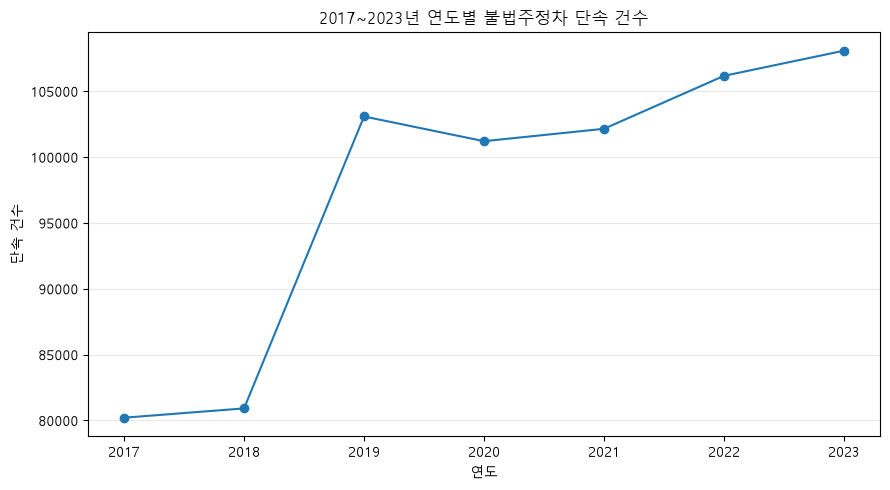

In [4]:
# 연도별 불법주정차 건수를 계산합니다.
year_count = df.groupby("연도").size()

# 계산 결과를 확인합니다.
print(year_count)

# 연도별 변화는 시간의 흐름이 중요하므로 선그래프로 나타냅니다.
plt.figure(figsize=(9, 5))
plt.plot(year_count.index, year_count.values, marker="o")
plt.title("2017~2023년 연도별 불법주정차 단속 건수")
plt.xlabel("연도")
plt.ylabel("단속 건수")
plt.xticks(year_count.index)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("images/date_year_count.png", dpi=150, bbox_inches="tight")
plt.show()

월
1     49695
2     51615
3     52521
4     49939
5     53309
6     58599
7     64351
8     58874
9     51555
10    62559
11    66382
12    62429
dtype: int64


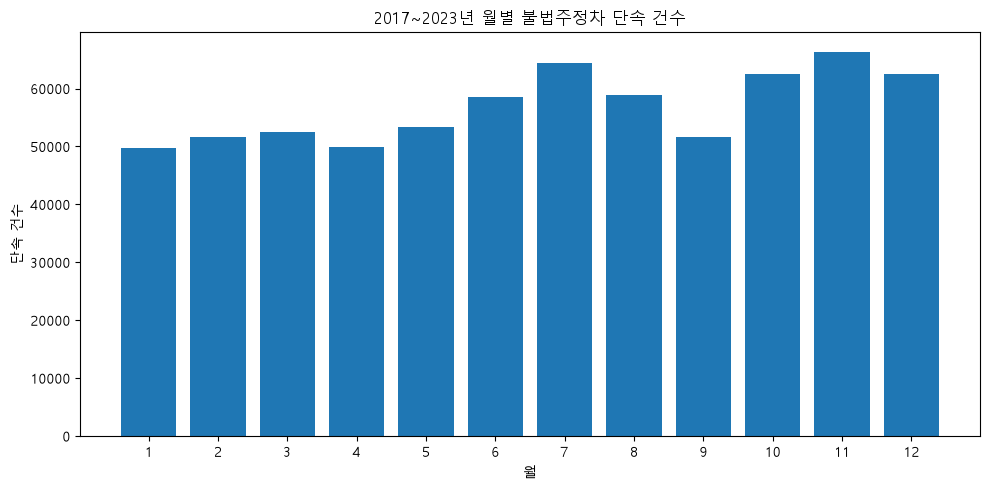

In [5]:
# 전체 기간을 기준으로 월별 불법주정차 건수를 계산합니다.
month_count = df.groupby("월").size().reindex(range(1, 13))

# 계산 결과를 확인합니다.
print(month_count)

# 1월부터 12월까지의 건수를 막대그래프로 비교합니다.
plt.figure(figsize=(10, 5))
plt.bar(month_count.index, month_count.values)
plt.title("2017~2023년 월별 불법주정차 단속 건수")
plt.xlabel("월")
plt.ylabel("단속 건수")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig("images/date_month_count.png", dpi=150, bbox_inches="tight")
plt.show()

요일
월요일    119178
화요일    114900
수요일    113784
목요일    112078
금요일    113825
토요일     51595
일요일     56468
dtype: int64


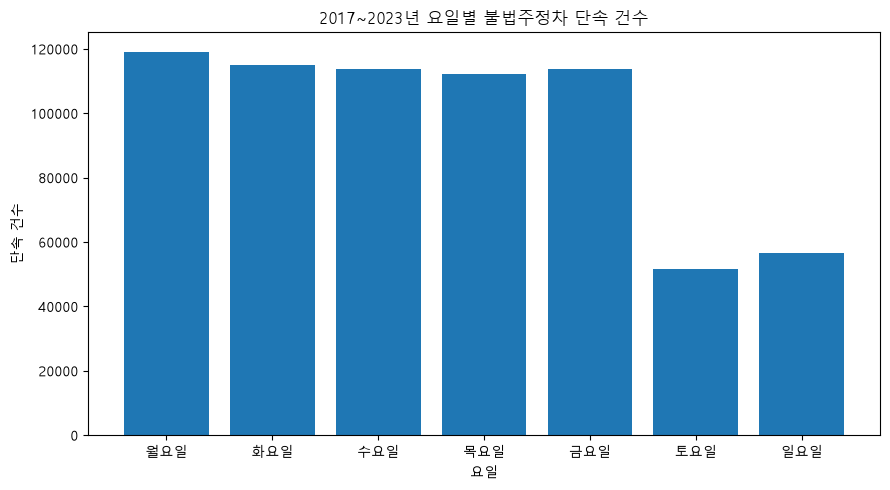

In [6]:
# 월요일부터 일요일까지 원하는 순서로 정렬하기 위한 리스트입니다.
weekday_order = ["월요일", "화요일", "수요일", "목요일", "금요일", "토요일", "일요일"]

# 요일별 불법주정차 건수를 계산하고 월~일 순서로 정렬합니다.
weekday_count = df.groupby("요일").size().reindex(weekday_order)

# 계산 결과를 확인합니다.
print(weekday_count)

# 요일별 건수를 막대그래프로 비교합니다.
plt.figure(figsize=(9, 5))
plt.bar(weekday_count.index, weekday_count.values)
plt.title("2017~2023년 요일별 불법주정차 단속 건수")
plt.xlabel("요일")
plt.ylabel("단속 건수")
plt.tight_layout()
plt.savefig("images/date_weekday_count.png", dpi=150, bbox_inches="tight")
plt.show()

월,1,2,3,4,5,6,7,8,9,10,11,12
연도,,,,,,,,,,,,
2017,6023,7860,8263,6742,6147,6989,7553,6699,5582,4332,6716,7305
2018,7032,4447,6516,6376,5685,6005,7893,7460,5296,8205,8472,7530
2019,7711,6196,7757,7443,7079,7567,9677,10324,8035,10396,10479,10422
2020,8280,8863,1015,1183,6843,10638,10817,11031,9784,11233,11678,9844
2021,8306,5948,9575,9994,8995,8962,8935,5243,7302,9380,9996,9515
2022,7437,9196,9414,8513,9199,9229,9952,8944,7342,9440,9812,7694
2023,4906,9105,9981,9688,9361,9209,9524,9173,8214,9573,9229,10119


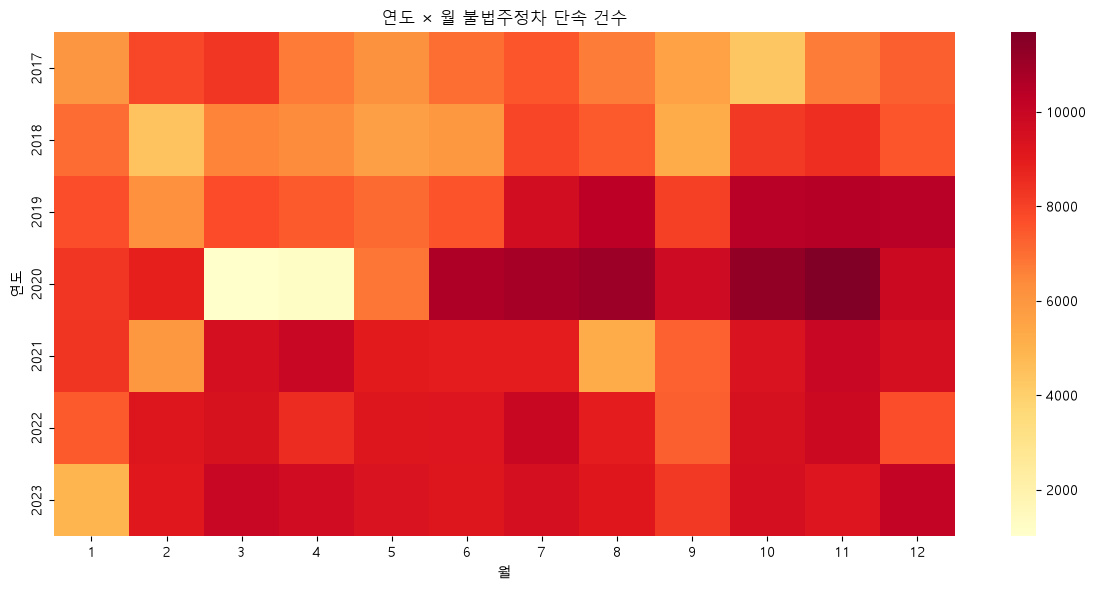

In [7]:
# 연도와 월을 기준으로 단속 건수를 교차 집계합니다.
year_month = df.groupby(["연도", "월"]).size().unstack(fill_value=0)

# 교차표를 확인합니다.
display(year_month)

# 연도별 월별 패턴을 한눈에 보기 위해 히트맵으로 나타냅니다.
plt.figure(figsize=(12, 6))
sns.heatmap(year_month, cmap="YlOrRd")
plt.title("연도 × 월 불법주정차 단속 건수")
plt.xlabel("월")
plt.ylabel("연도")
plt.tight_layout()
plt.savefig("images/date_year_month_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# 가장 많은 연도, 월, 요일을 찾아 간단하게 출력합니다.
top_year = year_count.idxmax()
top_month = month_count.idxmax()
top_weekday = weekday_count.idxmax()

print("단속 건수가 가장 많은 연도:", top_year, "년")
print("단속 건수가 가장 많은 월:", top_month, "월")
print("단속 건수가 가장 많은 요일:", top_weekday)

print("\n※ 이 결과는 날짜 기준 집계이며, 이후 시간대·장소 분석과 함께 해석합니다.")

단속 건수가 가장 많은 연도: 2023 년
단속 건수가 가장 많은 월: 11 월
단속 건수가 가장 많은 요일: 월요일

※ 이 결과는 날짜 기준 집계이며, 이후 시간대·장소 분석과 함께 해석합니다.
